In [3]:
# reload modules before execution (for the changing code in src)
%load_ext autoreload
%autoreload 2

In [27]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))
import src.utils as utils

import pandas as pd

import matplotlib.pyplot as plt

In [80]:
findex_db_name = '../data/raw/Findex.db'
sql_folder = '../sql/'

pic_folder = '../articles/unit_measure/pic/'

In [25]:
spreads_tuples = utils.run_sql(findex_db_name, sql_folder + 'spreads.sql')
spreads = pd.DataFrame(spreads_tuples, columns = ['unit_measure', 'unit_measure_label', 'country_id', 'country_name', 'observation_date', 'min_derived', 'max_derived', 'spread'])

In [58]:
# extract maximum spread for each unit_measure value
max_spreads = spreads.groupby(['unit_measure', 'unit_measure_label'], as_index = False)['spread'].max().sort_values(by = ['spread'])
max_spreads['spread'] = max_spreads['spread'].round(4)

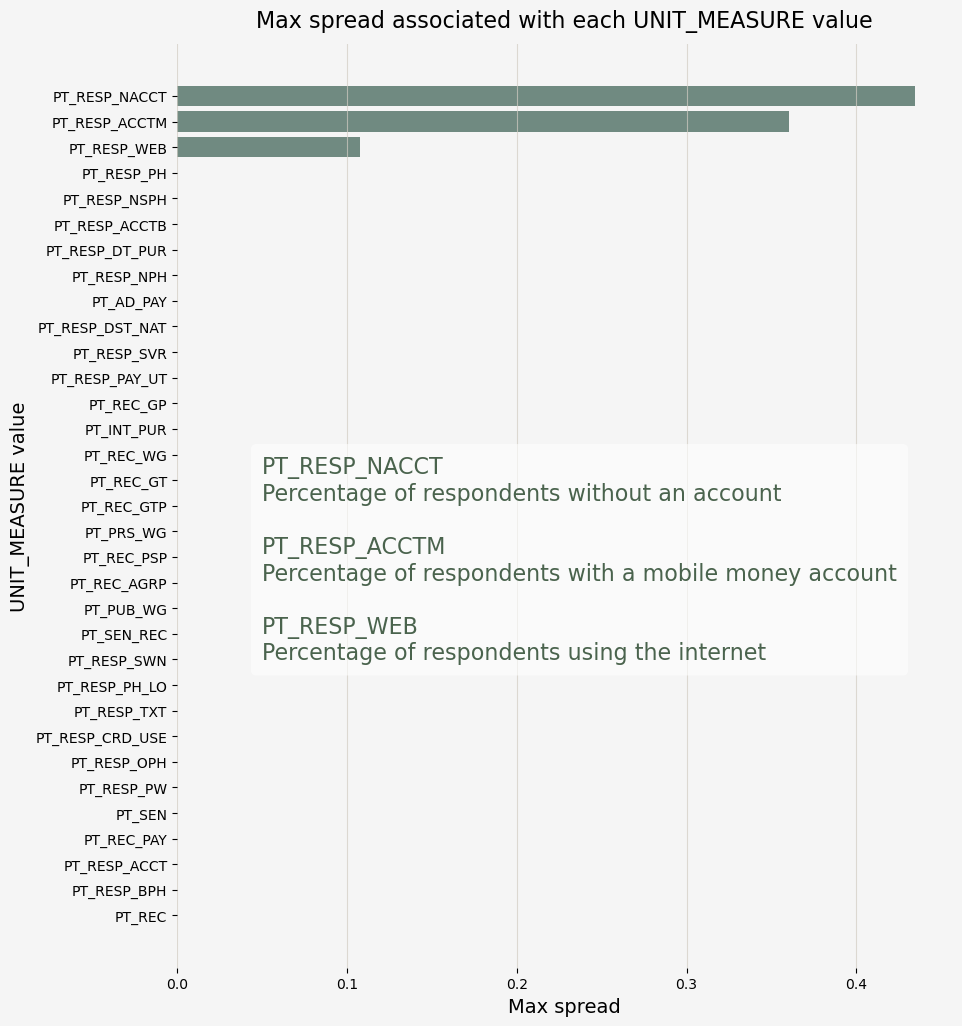

In [91]:
annotation_data = (max_spreads[max_spreads['spread'] > 0]
    .sort_values(by = ['spread'], ascending = False)[['unit_measure', 'unit_measure_label']]
    .values)

annotation_text = '\n\n'.join(
    f'{unit_measure}\n{label}'
    for unit_measure, label in annotation_data
)

utils.pretty_hbar(max_spreads['unit_measure'], max_spreads['spread'],
           plot_title = "Max spread associated with each UNIT_MEASURE value",
           x_axis_title = "Max spread",
           y_axis_title = "UNIT_MEASURE value",
           annotation={
                    "bbox": {
                            "boxstyle": "round,pad=0.5,rounding_size=0.25",
                            "fc": "white",          # fill color
                            "ec": "none",
                            #"ec": "#a5c4b6",
                            #"lw": 1,
                            "alpha": 0.6
                    },
                    "text": annotation_text,
                    "xy": (0, 32),
                    "xytext": (0.05, 10),
                    "color": "#4a634d",
                    "fontsize": 16
                },
           save_file = pic_folder + 'spreads_hbar.png')